# HGQA mk07 — End-to-End Hybrid Quantum-Genetic Pipeline

Full pipeline: **Data → Grid → QUBO → Pruning → QAOA → GA (3 modes) → Comparison**

| Step | What happens |
|------|-------------|
| 1 | Load dataset; compute grid + cell weights |
| 2 | Build and calibrate QUBO (H1–H6, H5 separate) |
| 3 | Three-tier cell pruning; remap to qubit space 0..K-1 |
| 4 | QAOA (statevector if K≤25, MPS if 25<K≤120) |
| 5 | GA — QAOA-seeded, random-seeded, greedy-seeded |
| 6 | Convergence plot + score comparison table |

**Key invariant:** `run_ga` takes `Q_pruned` (qubit indices 0..K-1), not `Q_obj` (original cell IDs).
`qaoa_results_to_chromosomes` converts QAOA output directly — no `cell_to_qubit` needed.
`run_ga` returns `best_solution` as original cell IDs (via internal `qubit_to_cell` lookup).


In [1]:
import sys
from pathlib import Path

_proj_root = Path.cwd().parent
if str(_proj_root / 'src') not in sys.path:
    sys.path.insert(0, str(_proj_root / 'src'))

DATA_DIR = str(_proj_root / 'data')
print(f'Project root: {_proj_root}')
print(f'src in sys.path: {str(_proj_root / "src") in sys.path}')


Project root: /Users/abhimuvva/Documents/Proj_HGQA
src in sys.path: True


In [2]:
import math
import os
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tabulate import tabulate

from data_loader import load_dataset, print_dataset_summary
from helpers import (
    divide_graph_into_parts,
    calculate_cell_weights,
    plot_cell_weights,
    plot_qubo_diagonal,
    print_weight_summary,
    suggest_parameters,
    print_parameter_suggestions,
)
from qubo_builder import (
    build_qubo,
    evaluate_solution,
    calibrate_alphas,
    print_qubo_diagnostics,
    brute_force_ranking,
)
from qaoa_builder import run_qaoa, run_qaoa_mps, print_qaoa_results
from cell_pruner import (
    prune_cells,
    remap_qubo_for_qaoa,
    translate_results,
    compute_solo_scores,
)
from ga_solver import run_ga, qaoa_results_to_chromosomes


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Load dataset
# ─────────────────────────────────────────────────────────────────────────────
# dataset_small_city.xlsx   — 15 POIs, m=4  (K typically ≤25 → statevector QAOA)
# dataset_medium_city.xlsx  — 25 POIs, m=5  (K ~20-50 → may use MPS-QAOA)
# dataset_large_city.xlsx   — 40 POIs, m=7  (K ~50-100 → MPS-QAOA)
# dataset_metro_region.xlsx — 59 POIs, m=10 (stress test, K>100 → GA only)

DATASET_FILE = os.path.join(DATA_DIR, "dataset_large_city.xlsx")

data = load_dataset(DATASET_FILE)
print_dataset_summary(data)

points_of_interest       = data['pois']
existing_charging_points = data['existing_chargers']
gas_stations             = data['gas_stations']
M                        = data['m']
X_MIN, X_MAX             = data['x_min'], data['x_max']
Y_MIN, Y_MAX             = data['y_min'], data['y_max']

SCALE_FACTOR = 5.0
MIN_WEIGHT   = 0.5
N_QUBITS     = 400   # small_city→100 | medium→196 | large→256 | metro→450


Dataset: large_city
  40 POIs, dense downtown + commercial + suburban, m=7. MPS-QAOA territory.
  Area: [0.0, 35.0] × [0.0, 30.0]
  POIs: 40  |  Chargers: 8  |  Gas: 8  |  m=7
  Density range: [0.27, 0.97]  mean=0.55


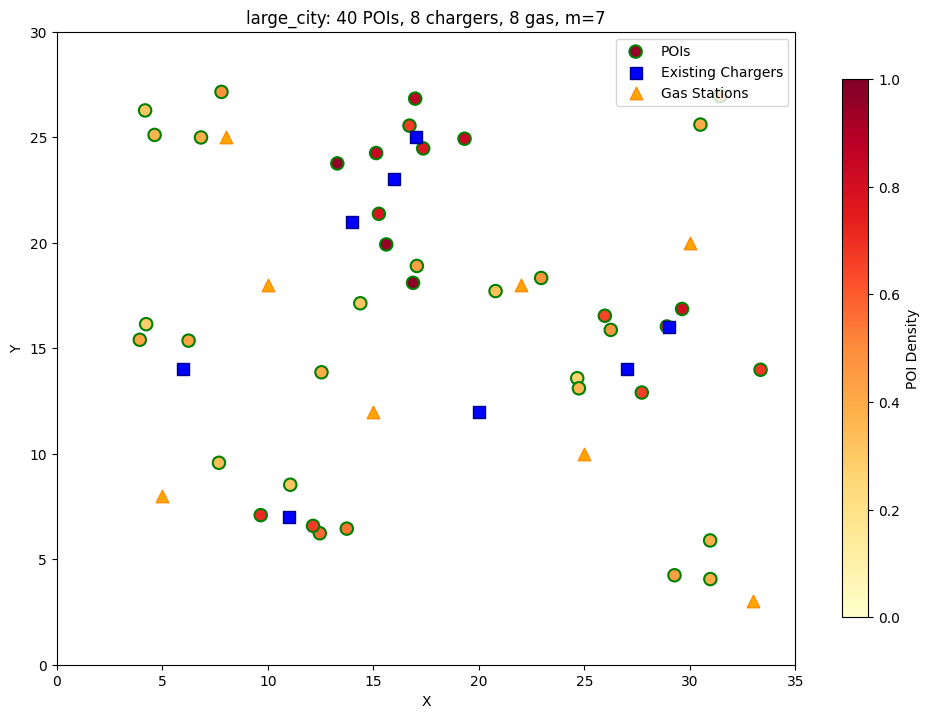

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Input data visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    [p[0] for p in points_of_interest],
    [p[1] for p in points_of_interest],
    c=[p[2] for p in points_of_interest],
    cmap='YlOrRd', edgecolors='green', linewidths=1.5,
    s=80, vmin=0, vmax=1, zorder=5, label='POIs',
)
plt.colorbar(sc, ax=ax, label='POI Density', shrink=0.7)

if existing_charging_points:
    ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
               s=80, zorder=5, edgecolors='darkblue', linewidths=1, label='Existing Chargers')
if gas_stations:
    ax.scatter(*zip(*gas_stations), color='orange', marker='^',
               s=80, zorder=5, edgecolors='darkorange', linewidths=1, label='Gas Stations')

ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(
    f"{data['dataset_name']}: {len(points_of_interest)} POIs, "
    f"{len(existing_charging_points)} chargers, {len(gas_stations)} gas, m={M}"
)
ax.legend(loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


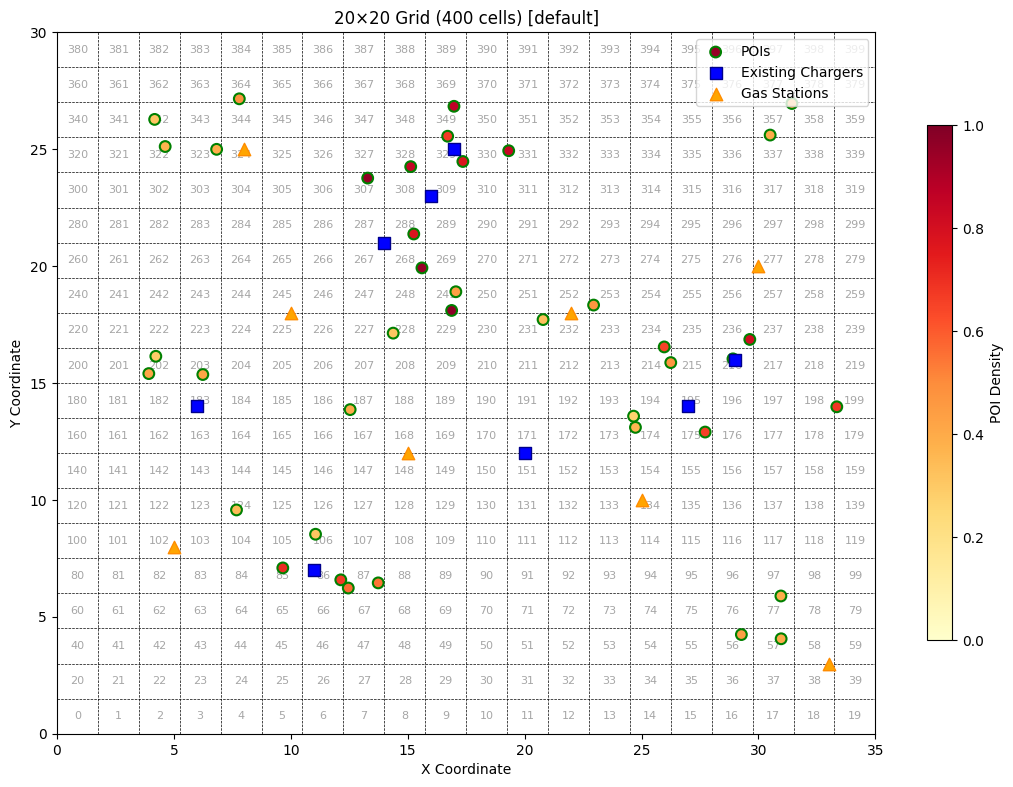

  Grid Info:
    Grid   56 (row=2, col=16): 1 POI(s) [densities: 0.44]
    Grid   57 (row=2, col=17): 1 POI(s) [densities: 0.40]
    Grid   58 (row=2, col=18): 1 gas station(s)
    Grid   77 (row=3, col=17): 1 POI(s) [densities: 0.39]
    Grid   85 (row=4, col=5): 1 POI(s) [densities: 0.71]
    Grid   86 (row=4, col=6): 1 POI(s) [densities: 0.67] | 1 charger(s)
    Grid   87 (row=4, col=7): 2 POI(s) [densities: 0.57, 0.55]
    Grid  102 (row=5, col=2): 1 gas station(s)
    Grid  106 (row=5, col=6): 1 POI(s) [densities: 0.31]
    Grid  124 (row=6, col=4): 1 POI(s) [densities: 0.34]
    Grid  134 (row=6, col=14): 1 gas station(s)
    Grid  168 (row=8, col=8): 1 gas station(s)
    Grid  171 (row=8, col=11): 1 charger(s)
    Grid  174 (row=8, col=14): 1 POI(s) [densities: 0.36]
    Grid  175 (row=8, col=15): 1 POI(s) [densities: 0.66]
    Grid  183 (row=9, col=3): 1 charger(s)
    Grid  187 (row=9, col=7): 1 POI(s) [densities: 0.40]
    Grid  194 (row=9, col=14): 1 POI(s) [densities: 0.27]

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Grid discretization
# ─────────────────────────────────────────────────────────────────────────────

grid_details, plot_deets = divide_graph_into_parts(
    x_min=X_MIN, x_max=X_MAX, y_min=Y_MIN, y_max=Y_MAX,
    num_qubits=N_QUBITS,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    grid_division="default",
)


CELL WEIGHT SUMMARY
------------------------  ---------
Total cells               400
Cells with POIs           35 (8.8%)
Total aggregated density  22.16
Max weight                5.00
Min non-zero weight       0.88
Total gas stations        8
Total existing chargers   8
------------------------  ---------

TOP 10 CELLS BY WEIGHT (Grid Data Table):
  Grid ID    Row    Col    # POIs    Raw    Norm    Weight    Gas Sta.    Chargers
---------  -----  -----  --------  -----  ------  --------  ----------  ----------
      349     17      9         2   1.54   1         5               0           0
      249     12      9         2   1.41   0.916     4.578           0           0
       87      4      7         2   1.12   0.727     3.636           0           0
      307     15      7         1   0.96   0.623     3.117           0           0
      268     13      8         1   0.95   0.617     3.084           0           0
      328     16      8         1   0.85   0.552     2.76           

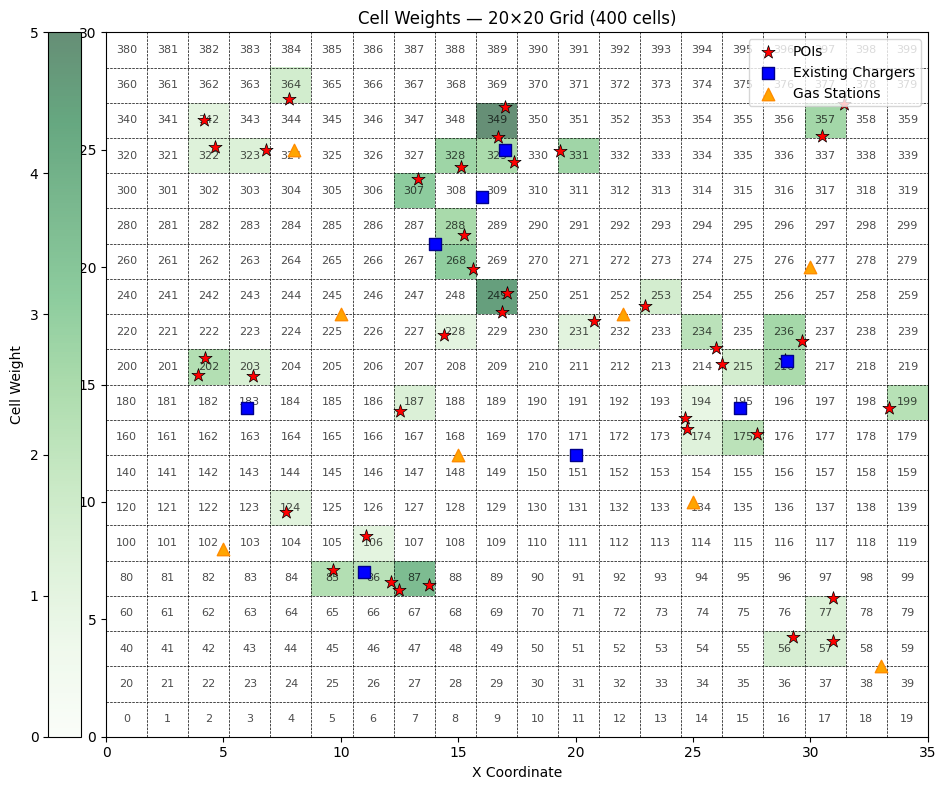

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Cell weight calculation
# ─────────────────────────────────────────────────────────────────────────────

cell_weights = calculate_cell_weights(
    grid_details, scale_factor=SCALE_FACTOR, min_weight=MIN_WEIGHT
)
print_weight_summary(cell_weights, grid_details, top_n=10)

plot_cell_weights(
    plot_deets, grid_details, cell_weights,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True, show_weight_values=True,
    cell_cmap='Greens', poi_style='solid_red',
)


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Parameter suggestion (FA-002)
# ─────────────────────────────────────────────────────────────────────────────

params = suggest_parameters(grid_details, cell_weights, plot_deets, m=M)
print_parameter_suggestions(params)

a          = params['alpha']
r          = params['radii']
t          = params['intra']
lambda_val = params['lambda']


SUGGESTED PARAMETERS

Local Radii:
Radius                                      Value
----------------------------------------  -------
R₁  — H1 POI attraction radius                  6
Rₛ  — service gap radius (matches R₁)           6
R₃  — H3 existing charger penalty radius        3
R₄  — H4 new charger spacing radius             4
R₆  — H6 coverage redundancy radius             3

Objective Weights (α):
Parameter                                     Value
------------------------------------------  -------
α₁  — H1 POI attraction         [dominant]   3
α₂  — H2 gas station bonus                   0.5
α₃  — H3 existing charger penalty            1.11
α₄  — H4 new charger spacing                 0.5
α₅  — H5 constraint  (applied to λ)          1
α₆  — H6 coverage redundancy                 0.2746

Intra-term Magnitudes:
Parameter                                  Value
---------------------------------------  -------
β  — gas station bonus magnitude               1
γ  — existing charger 

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. QUBO construction
# ─────────────────────────────────────────────────────────────────────────────

Q_obj, h5_params, diags = build_qubo(
    grid_details, cell_weights, plot_deets, m=M,
    alpha1=a['a1'], alpha2=a['a2'], alpha3=a['a3'],
    alpha4=a['a4'], alpha5=a['a5'], alpha6=a['a6'],
    beta=t['beta'], gamma=t['gamma'], delta=t['delta'], epsilon=t['epsilon'],
    lam=lambda_val,
    R1=r['R1'], Rs=r['Rs'], R3=r['R3'], R4=r['R4'], R6=r['R6'],
)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Post-build calibration
# ─────────────────────────────────────────────────────────────────────────────

params_flat = {
    'alpha1': a['a1'], 'alpha2': a['a2'], 'alpha3': a['a3'],
    'alpha4': a['a4'], 'alpha5': a['a5'], 'alpha6': a['a6'],
    'beta': t['beta'], 'gamma': t['gamma'], 'delta': t['delta'], 'epsilon': t['epsilon'],
    'lam': lambda_val,
    'R1': r['R1'], 'Rs': r['Rs'], 'R3': r['R3'], 'R4': r['R4'], 'R6': r['R6'],
}

params_flat, needs_rebuild = calibrate_alphas(Q_obj, params_flat, diags, verbose=True)
if needs_rebuild:
    print("\nRebuilding Q_obj with calibrated parameters...")
    Q_obj, h5_params, diags = build_qubo(
        grid_details, cell_weights, plot_deets, m=M, **params_flat,
    )
    print("Rebuild complete.")

print_qubo_diagnostics(diags, params=params_flat)


CALIBRATE_ALPHAS
  Diagonal peak:  2.9303
  Target (×0.5): 1.4651
  H4 actual peak: 0.2500  ✓ OK
  H6 actual peak: 1.5000  ✗ TOO HIGH
  Adjustments:
  α6: 0.2746 → 0.2682  (H6 peak 1.5000 > target 1.4651)
  → Rebuild Q_obj with updated params.

Rebuilding Q_obj with calibrated parameters...
Rebuild complete.
QUBO CONSTRUCTION DIAGNOSTICS (Q_obj — H1 through H6, H5 separate)

Grid:  N=400 cells,  m=7 new chargers
  POI cells:            35
  Cells w/ chargers:    8
  Individual chargers:  8  (E_all — counts: {288: 1, 195: 1, 329: 1, 171: 1, 309: 1, 86: 1, 183: 1, 216: 1})
  Radii: R1=6, Rs=6, R3=3, R4=4, R6=3

Call parameters:
  alpha1       = 3.0
  alpha2       = 0.5
  alpha3       = 1.11
  alpha4       = 0.5
  alpha5       = 1.0
  alpha6       = 0.2682
  beta         = 1.0
  gamma        = 1.0
  delta        = 1.0
  epsilon      = 1.0
  lam          = 122.5
  R1           = 6
  Rs           = 6
  R3           = 3
  R4           = 4
  R6           = 3

NORMALIZATION SCALES (raw max-abs

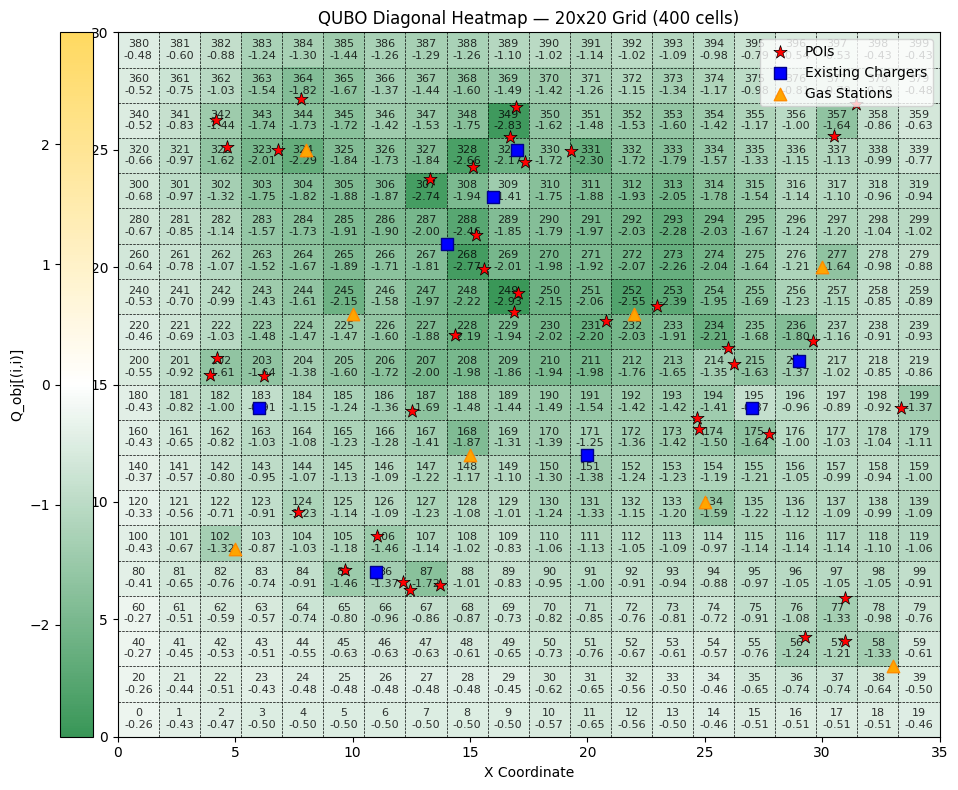

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. QUBO diagonal heatmap
# ─────────────────────────────────────────────────────────────────────────────

plot_qubo_diagonal(
    plot_deets, grid_details, Q_obj,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True,
    show_qubo_values=True,
    show_grid_ids=True,
    poi_style='solid_red',
)


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. Brute force (only if C(N,m) ≤ 500 000)
# ─────────────────────────────────────────────────────────────────────────────

n_combos = math.comb(N_QUBITS, M)
print(f"C({N_QUBITS},{M}) = {n_combos:,}")

if n_combos <= 500_000:
    top_solutions = brute_force_ranking(Q_obj, N=N_QUBITS, m=M, top_k=10)
    print(f"\nTop 10 solutions (full Q):")
    for rank, (score, sol) in enumerate(top_solutions, 1):
        print(f"  {rank:>2}. score={score:>8.4f}  cells={list(sol)}")
    full_optimal_score = top_solutions[0][0]
    full_optimal_cells = set(top_solutions[0][1])
else:
    print("Too large for brute force — skipping.")
    top_solutions      = None
    full_optimal_score = None
    full_optimal_cells = None


C(400,7) = 308,364,541,201,200
Too large for brute force — skipping.


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 10. Cell pruning (three-tier)
#     TIER3_KEEP is exposed so the validation cell can compare against it
#     and re-prune with a better value if any check fails.
# ─────────────────────────────────────────────────────────────────────────────

TIER3_KEEP = 3   # default; validation may override this

surviving_cells, prune_report = prune_cells(
    Q_obj, N=N_QUBITS, m=M,
    num_cols=plot_deets['num_cols'],
    R4=r['R4'],
    tier3_keep=TIER3_KEEP,
    verbose=True,
)

if full_optimal_cells is not None:
    preserved = full_optimal_cells.issubset(set(surviving_cells))
    print(f"\nFull-Q optimal {sorted(full_optimal_cells)} preserved? "
          f"{'YES' if preserved else 'NO'}")


CELL PRUNING
  Starting cells: 400
  Solo scores: 400 negative, 0 zero, 0 positive
  Solo range: [-2.9303, -0.2552]

  Tier 1 (dead cells): 0 pruned, 400 remain  (0 zero-solo cells kept near competitive)
  Tier 2 (bound elim): 0 pruned, 400 remain  (ref score=-15.2912)
  Tier 3 (dedup):      167 pruned, 233 remain  (106 clusters, sizes=[4, 53, 4, 2, 51, 2, 2, 4, 1, 1, 2, 4, 2, 1, 1, 55, 1, 1, 4, 3, 1, 3, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 3, 20, 1, 1, 5, 1, 2, 6, 2, 4, 1, 2, 2, 2, 1, 1, 18, 12, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1, 2, 1, 4, 2, 1, 2, 1, 3, 7, 1, 1, 1, 5, 1, 1, 1, 1, 4, 1, 1, 4, 2, 1, 1, 1, 2, 3, 1, 4, 2, 1, 1, 1, 1, 1, 4, 3, 1, 2, 3, 2, 2])

  RESULT: 400 → 233 cells (42% reduction)
  Surviving IDs: [0, 11, 20, 35, 36, 37, 38, 40, 49, 52, 55, 56, 57, 58, 59, 60, 64, 65, 66, 74, 77, 79, 80, 81, 82, 83, 84, 85, 86, 87, 100, 101, 102, 103, 104, 106, 115, 116, 117, 118, 120, 121, 122, 123, 134, 136, 139, 140, 141, 142, 143, 160, 161, 162, 168, 173, 174, 175, 179, 180, 181, 1

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 11. Pruning validation + adaptive re-prune
#
#     Seven checks run against current surviving_cells:
#       1-4  Quality (over-pruning): greedy, random, GA, neighbor coverage
#       5    Sensitivity sweep → knee_keep
#       6    Over-keeping (efficiency): current_K vs K_at_knee
#       7    Perturbation selection frequency: identifies low-evidence survivors
#
#     Actions taken automatically:
#       Checks 1-4 FAIL → re-prune with knee_keep (quality fix)
#       Check  6   WARN/FAIL (and quality ok) → re-prune with knee_keep (efficiency fix)
#       Check  7   always INFO; printed as diagnostic, no auto-action
# ─────────────────────────────────────────────────────────────────────────────

from pruning_validation import run_pruning_validation, print_pruning_validation_report

validation = run_pruning_validation(
    Q_obj=Q_obj,
    N=N_QUBITS,
    m=M,
    num_cols=plot_deets["num_cols"],
    R4=r["R4"],
    surviving_cells=surviving_cells,
    tier3_keep_values=[2, 3, 4, 5, M],
    random_samples=10_000,
    ga_generations=500,
    ga_population=100,
    seed=42,
)

print_pruning_validation_report(validation)

# ── Adaptive re-prune: quality (checks 1-4) ──────────────────────────────────
c1 = validation["check_1_greedy_comparison"]
c2 = validation["check_2_random_sampling"]
c3 = validation["check_3_ga_convergence"]
c4 = validation["check_4_neighbor_coverage"]
c5 = validation["check_5_sensitivity_sweep"]

any_fail = any(v["status"] == "FAIL" for v in [c1, c2, c3, c4])
knee_keep = c5["knee_keep"]

if not any_fail:
    print("\nAll quality checks PASS/INFO — no quality-driven re-prune needed.")
    tier3_keep_used = TIER3_KEEP

elif knee_keep is not None and knee_keep != TIER3_KEEP:
    print(f"\n{'='*60}")
    print(f"FAIL detected. Re-pruning with tier3_keep={knee_keep} (sweep knee).")
    print(f"{'='*60}")
    surviving_cells, prune_report = prune_cells(
        Q_obj, N=N_QUBITS, m=M,
        num_cols=plot_deets["num_cols"],
        R4=r["R4"],
        tier3_keep=knee_keep,
        verbose=True,
    )
    tier3_keep_used = knee_keep
    print(f"\nRe-pruned: {N_QUBITS} → {len(surviving_cells)} cells")

    if full_optimal_cells is not None:
        preserved = full_optimal_cells.issubset(set(surviving_cells))
        print(f"Full-Q optimal still preserved? {'YES' if preserved else 'NO'}")

else:
    sweep_rows = c5["rows"]
    gap_thr = c1["threshold_pct"]
    passing = [row for row in sweep_rows if row["greedy_gap_vs_full_pct"] <= gap_thr]
    if passing:
        best_row = min(passing, key=lambda row: row["K"])
        fallback_keep = best_row["tier3_keep"]
    else:
        fallback_keep = max(row["tier3_keep"] for row in sweep_rows)

    if fallback_keep != TIER3_KEEP:
        print(f"\n{'='*60}")
        print(f"FAIL detected (no clear knee). Re-pruning with tier3_keep={fallback_keep}.")
        print(f"{'='*60}")
        surviving_cells, prune_report = prune_cells(
            Q_obj, N=N_QUBITS, m=M,
            num_cols=plot_deets["num_cols"],
            R4=r["R4"],
            tier3_keep=fallback_keep,
            verbose=True,
        )
        tier3_keep_used = fallback_keep
        print(f"\nRe-pruned: {N_QUBITS} → {len(surviving_cells)} cells")
    else:
        print(f"\nFAIL detected but best sweep keep={fallback_keep} equals current. "
              "Proceeding with current pruning.")
        tier3_keep_used = TIER3_KEEP

print(f"\ntier3_keep_used={tier3_keep_used}  surviving_cells={len(surviving_cells)}")


# ── Adaptive re-prune: over-keeping (check 6) ────────────────────────────────
c6 = validation["check_6_overkeeping"]
_live_K     = len(surviving_cells)          # may differ from stale c6["current_K"]
_k_at_knee  = c6.get("K_at_knee")
_fail_ratio = c6.get("fail_ratio", 1.50)
_still_over = _k_at_knee is not None and _live_K > _k_at_knee * _fail_ratio

if _still_over and knee_keep is not None and knee_keep != tier3_keep_used:
    # Standard path: knee is at a smaller tier3_keep — re-prune to it.
    _c6_target = knee_keep
elif _still_over and knee_keep is not None:
    # knee_keep == tier3_keep_used but K is still too large.
    # This happens when the sweep used enforce_tier3_keep_at_least_m=False
    # (giving a lower K_at_knee than the actual prune).
    # Fall back to the largest tier3_keep < current that passes quality.
    _gap_thr = c1["threshold_pct"]
    _candidates = [
        r for r in c5["rows"]
        if r["tier3_keep"] < tier3_keep_used
        and r["greedy_gap_vs_full_pct"] <= _gap_thr
    ]
    _c6_target = max((r["tier3_keep"] for r in _candidates), default=None)
else:
    _c6_target = None

if _c6_target is not None:
    print(f"\n{'='*60}")
    print(f"Check 6 {c6['status']}: over-keeping detected.")
    print(f"  live_K={_live_K}  K_at_knee={_k_at_knee}  ratio={_live_K/_k_at_knee:.2f}")
    print(f"  Re-pruning with tier3_keep={_c6_target}.")
    print(f"{'='*60}")
    surviving_cells, prune_report = prune_cells(
        Q_obj, N=N_QUBITS, m=M,
        num_cols=plot_deets["num_cols"],
        R4=r["R4"],
        tier3_keep=_c6_target,
        verbose=True,
    )
    tier3_keep_used = _c6_target
    print(f"\nRe-pruned: {N_QUBITS} → {len(surviving_cells)} cells")
elif c6["status"] in ("WARN", "FAIL") and not _still_over:
    print(f"\nCheck 6 {c6['status']} (stale): quality re-prune already reduced K to "
          f"{_live_K}, now within range of K_at_knee={_k_at_knee}.")
elif c6["status"] in ("WARN", "FAIL"):
    print(f"\nCheck 6 {c6['status']}: K={_live_K} vs K_at_knee={_k_at_knee} "
          f"— no smaller quality-passing tier3_keep found, cannot reduce further.")
else:
    print(f"\nCheck 6 {c6['status']}: K is within efficient range of K_at_knee.")

print(f"Final: tier3_keep_used={tier3_keep_used}  K={len(surviving_cells)}")


# ── Check 7: perturbation frequency diagnostic ────────────────────────────────
c7 = validation["check_7_perturbation_frequency"]
if c7.get("status") == "INFO":
    print(f"\nCheck 7 — Perturbation frequency ({c7['n_perturbations']} runs, "
          f"sigma={c7['sigma_scale']}×diag_std):")
    print(f"  K={c7['K']}  K_effective={c7['K_effective']}  "
          f"core={len(c7['core_cells'])} (>80%)  "
          f"competitive={len(c7['competitive_cells'])} (1-80%)  "
          f"marginal={len(c7['marginal_cells'])} (≤1%)")
    if c7["marginal_cells"]:
        print(f"  Low-evidence survivors: {c7['marginal_cells']}")
        print(f"  Consider tighter pruning if K_effective={c7['K_effective']} fits your qubit budget.")


TIER-3 SCALE VALIDATION
N=400  K=233  reduction=41.8%  m=7
Check 1 - Greedy comparison: PASS
  full=-15.2912  pruned=-15.2912  gap=0.00%  same_cells=True
Check 2 - Random sampling: PASS
  best full/pruned=-11.9678/-12.4501  mean full/pruned=-7.2523/-7.8220  p5 full/pruned=-9.2822/-9.8784
Check 3 - GA convergence: PASS
  best full/pruned=-15.3023/-15.3023  95% gen full/pruned=328/31
Check 4 - Neighbor coverage: PASS
  Every full-greedy cell kept at least one surviving d<=2 alternative.
Check 5 - Sensitivity sweep: PASS
  knee_keep=2
  keep= 2 -> K= 159  greedy=-15.2912  gap_vs_full=0.00%
  keep= 3 -> K= 187  greedy=-15.2912  gap_vs_full=0.00%
  keep= 4 -> K= 208  greedy=-15.2912  gap_vs_full=0.00%
  keep= 5 -> K= 218  greedy=-15.2912  gap_vs_full=0.00%
  keep= 7 -> K= 233  greedy=-15.2912  gap_vs_full=0.00%
Check 6 - Over-keeping: WARN
  current_K=233  K_at_knee=159  ratio=1.47  (PASS≤1.15x  WARN≤1.5x  FAIL>)
Check 7 - Perturbation frequency (50 runs): INFO
  K=233  K_effective=15  core

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. Remap QUBO to pruned qubit space (0..K-1)
#     Uses surviving_cells as finalized by the validation cell above
#     (re-pruned if any validation check failed).
# ─────────────────────────────────────────────────────────────────────────────

Q_pruned, cell_to_qubit, qubit_to_cell = remap_qubo_for_qaoa(Q_obj, surviving_cells)
K = len(surviving_cells)

print(f"Remapped: {N_QUBITS} → {K} qubits ({100*(1-K/N_QUBITS):.0f}% reduction)")
print(f"  Q_pruned entries : {len(Q_pruned)}")
print(f"  Search space     : C({K},{M}) = {math.comb(K, M):,}")
print(f"  tier3_keep used  : {tier3_keep_used}")

h5_params_pruned = {'lam': h5_params['lam'], 'alpha5': h5_params['alpha5'], 'm': M}


Remapped: 400 → 233 qubits (42% reduction)
  Q_pruned entries : 6998
  Search space     : C(233,7) = 6,753,818,290,868
  tier3_keep used  : 3


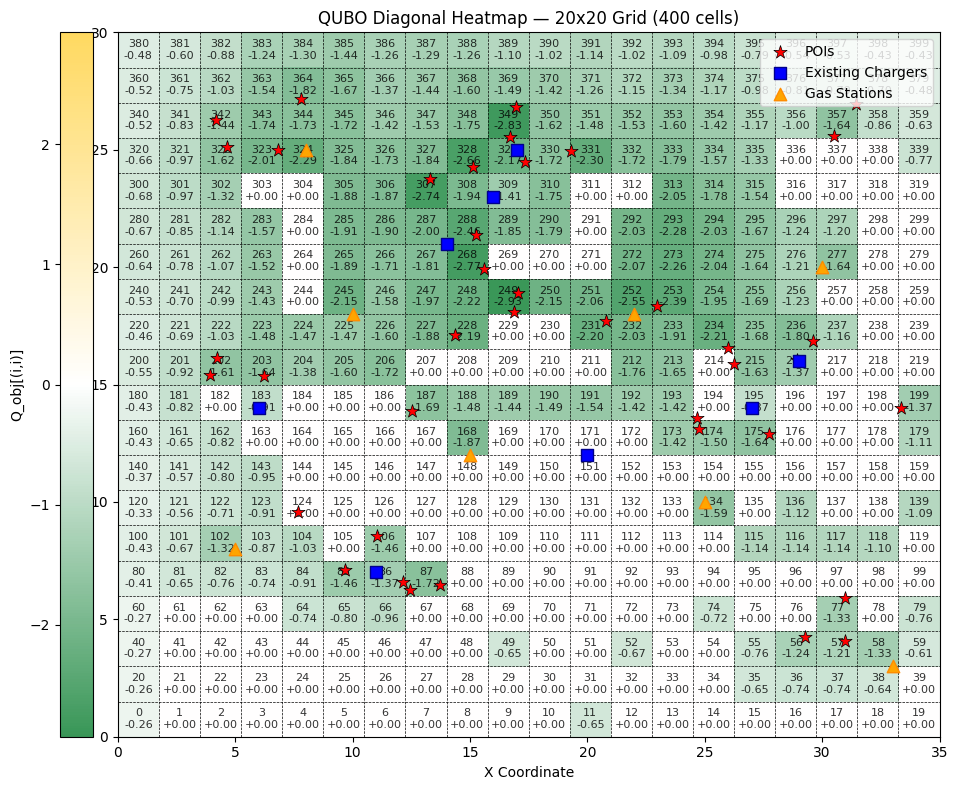

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 12. Pruned QUBO diagonal heatmap (converted back to original grid IDs)
# ─────────────────────────────────────────────────────────────────────────────

Q_pruned_on_grid = {
    (qubit_to_cell[i], qubit_to_cell[i]): val
    for (i, j), val in Q_pruned.items()
    if i == j
}

plot_qubo_diagonal(
    plot_deets, grid_details, Q_pruned_on_grid,
    points_of_interest=points_of_interest,
    existing_chargers=existing_charging_points,
    gas_stations=gas_stations,
    show_data_points=True,
    show_qubo_values=True,
    show_grid_ids=True,
    poi_style='solid_red',
)


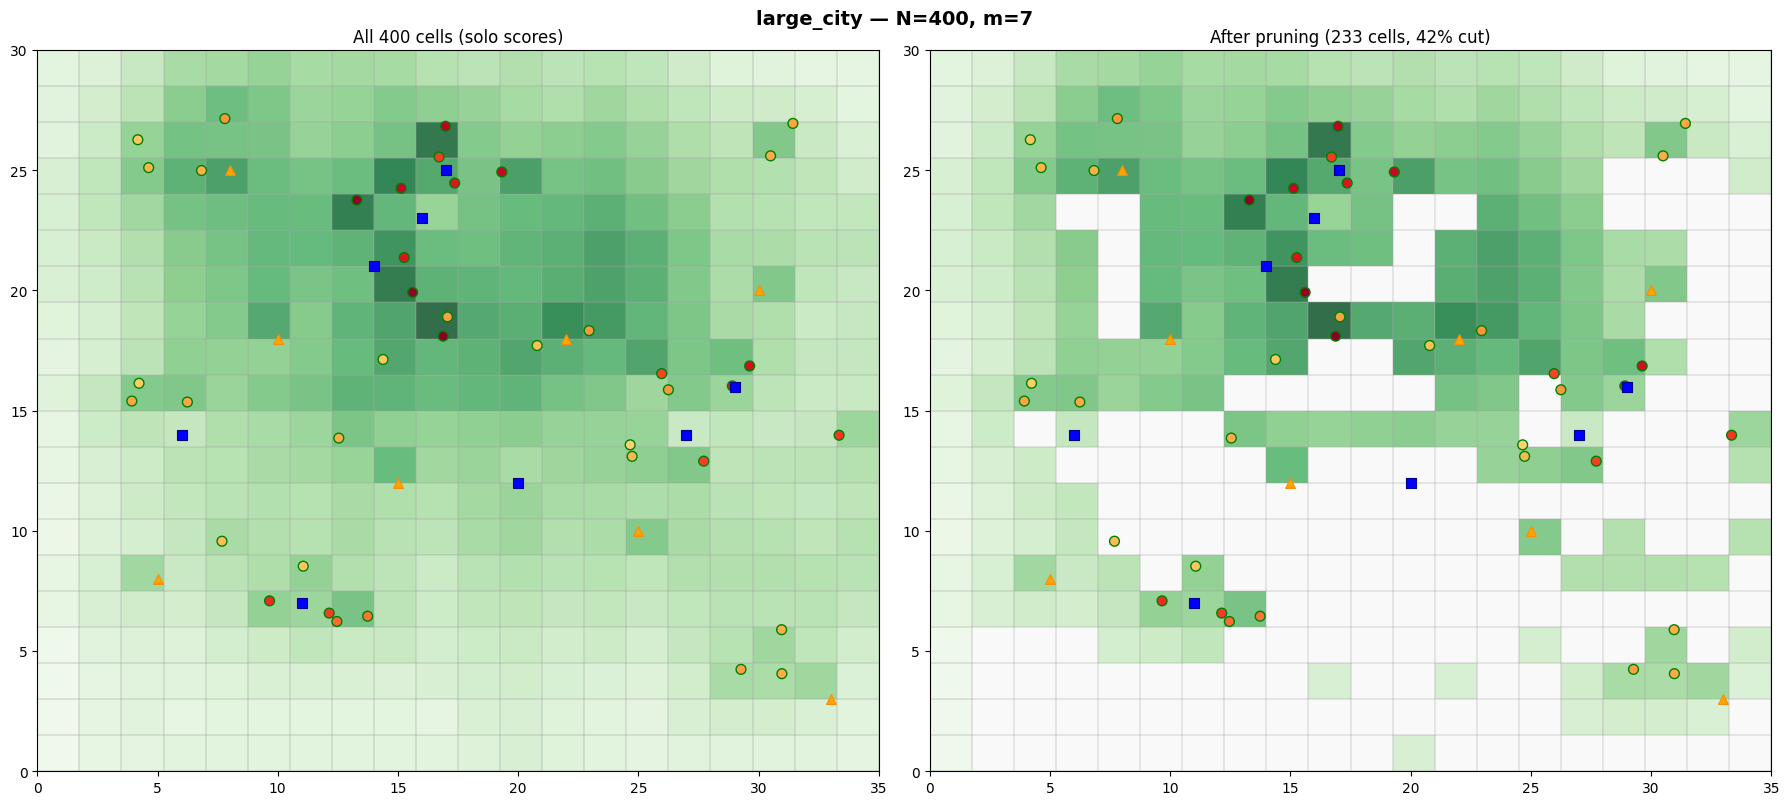

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 13. Pruning before / after visualization
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
solos    = compute_solo_scores(Q_obj, N_QUBITS)
num_rows = plot_deets['num_rows']
num_cols = plot_deets['num_cols']
cell_w   = plot_deets['cell_w']
cell_h   = plot_deets['cell_h']

for ax, title, highlight in zip(
    axes,
    [f'All {N_QUBITS} cells (solo scores)',
     f'After pruning ({K} cells, {100*(1-K/N_QUBITS):.0f}% cut)'],
    [set(range(N_QUBITS)), set(surviving_cells)],
):
    ax.set_facecolor('white')
    for i in range(num_cols + 1):
        ax.axvline(X_MIN + i * cell_w, color='gray', linestyle='-', linewidth=0.2)
    for j in range(num_rows + 1):
        ax.axhline(Y_MIN + j * cell_h, color='gray', linestyle='-', linewidth=0.2)

    for gid, info in grid_details.items():
        if gid in highlight:
            score = solos[gid]
            norm  = max(0, min(1, -score / 3.0))
            color = plt.cm.Greens(norm)
            alpha = 0.8
        else:
            color = (0.93, 0.93, 0.93)
            alpha = 0.3
        ax.add_patch(plt.Rectangle(
            (info['x_start'], info['y_start']), cell_w, cell_h,
            facecolor=color, alpha=alpha, edgecolor='lightgray', linewidth=0.2,
        ))

    if points_of_interest:
        ax.scatter([p[0] for p in points_of_interest],
                   [p[1] for p in points_of_interest],
                   c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                   edgecolors='green', linewidths=1, s=50, vmin=0, vmax=1, zorder=5)
    if existing_charging_points:
        ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
                   s=50, zorder=5, edgecolors='darkblue', linewidths=0.8)
    if gas_stations:
        ax.scatter(*zip(*gas_stations), color='orange', marker='^',
                   s=50, zorder=5, edgecolors='darkorange', linewidths=0.8)

    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')

plt.suptitle(
    f"{data['dataset_name']} — N={N_QUBITS}, m={M}",
    fontsize=14, fontweight='bold',
)
plt.tight_layout()
plt.show()


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# 17. QAOA on pruned Q  —  XY-ring-mixer mode (include_h5=False)
#
#     XY mixer swaps |01>↔|10>, preserving Hamming weight m — all sampled
#     bitstrings have exactly m ones, no H5 penalty or post-selection needed.
#     Circuit: |1^m 0^{K-m}> → [cost + XY-ring]^p → measure
#     Restarts run sequentially; each uses all cores via Aer BLAS/OpenMP.
# ─────────────────────────────────────────────────────────────────────────────

import os

_n_restarts = max(2, os.cpu_count() or 4)   # saturate available cores

# if K <= 25:
#     qaoa_results_pruned, qaoa_params = run_qaoa(
#         Q_pruned, h5_params_pruned,
#         N=K, m=M, p=3, max_iter=300, n_restarts=3, seed=42, verbose=True,
#     )
#     qaoa_mode = "statevector"

# el
if K <= 250:
    qaoa_results_pruned, qaoa_params = run_qaoa_mps(
        Q_pruned, h5_params_pruned,
        N=K, m=M,
        p=2,
        max_iter=150,          # per restart; total budget = max_iter × n_restarts
        shots=5000,
        n_restarts=_n_restarts,
        seed=42,
        verbose=True,
        max_bond_dimension=32,
        truncation_threshold=1e-10,
        include_h5=False,       # XY-ring mixer — no H5 needed
    )
    qaoa_mode = "mps"

else:
    print(f"K={K} too large for practical QAOA — skipping. GA will run standalone.")
    qaoa_results_pruned = None
    qaoa_params         = None
    qaoa_mode           = None

if qaoa_results_pruned is not None:
    qaoa_results_cells = translate_results(qaoa_results_pruned, qubit_to_cell)
    prob_label = "Prob" if qaoa_mode == "statevector" else "EmpProb"
    print(f"\nQAOA mode: {qaoa_mode}")
    print(f"\n{'Rank':<6} {'Score':>10} {prob_label:>10}   Cell IDs")
    print("─" * 70)
    for rank, (score, cells_list, prob) in enumerate(qaoa_results_cells, 1):
        print(f"  {rank:<4} {score:>10.4f} {prob:>10.6f}   {cells_list}")
else:
    qaoa_results_cells = None


QAOA MPS Pipeline: N=233, m=7, p=2, restarts=10, max_iter=150, shots=5000, top_k=11
  AerSimulator: method=matrix_product_state, bond_dim=32, trunc=1e-10, measure_algo=mps_apply_measure, threads=10
  XY-mixer QAOA: H5 excluded. Objective has 233 Z terms, 6765 ZZ terms. Feasibility guaranteed by Hamming-weight-preserving XY ring mixer.
  Circuit [XY-ring]: 4 params, ~46402 gates per restart (random initial state each restart)
  Sequential restarts: 10, up to 150 COBYLA evals each


/Users/abhimuvva/Documents/Proj_HGQA/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Restart 1/10  DONE  best=-7.7386:  25%|██▍       | 37/150 [31:02<1:34:49, 50.35s/eval]


  Restart 1/10: cost=-296.298955 (shifted), raw=-7.738578, evals=37


Restart 2/10  DONE  best=-9.0373:  27%|██▋       | 40/150 [14:12<39:04, 21.32s/eval]


  Restart 2/10: cost=-297.597726 (shifted), raw=-9.037349, evals=40


...

  Restart 8/10: cost=-298.880481 (shifted), raw=-10.320104, evals=38


Restart 9/10  DONE  best=-9.2344:  29%|██▉       | 44/150 [09:51<23:45, 13.45s/eval]


  Restart 9/10: cost=-297.794796 (shifted), raw=-9.234418, evals=44


Restart 10/10  DONE  best=-8.1735:  25%|██▌       | 38/150 [34:04<1:40:26, 53.80s/eval]


  Restart 10/10: cost=-296.733839 (shifted), raw=-8.173461, evals=38
  Best shifted cost: -298.880481 (raw: -10.320104)
  Feasible sampled shots (popcount=7): 5000/5000 = 1.0000
  Unique feasible sampled solutions: 67
  Returning top 11
  MPS metadata: {'matrix_product_state_max_bond_dimension': 32, 'matrix_product_state_truncation_threshold': 1e-10}

QAOA mode: mps

Rank        Score    EmpProb   Cell IDs
──────────────────────────────────────────────────────────────────────
  1      -11.8795   0.000200   [77, 116, 249, 324, 328, 332, 342]
  2      -11.8201   0.000200   [77, 116, 249, 324, 329, 333, 342]
  3      -11.5368   0.000200   [77, 116, 249, 324, 329, 331, 343]
  4      -11.3678   0.000800   [77, 116, 249, 324, 329, 332, 342]
  5      -11.3344   0.000200   [77, 115, 249, 324, 329, 331, 342]
  6      -11.3344   0.023800   [77, 116, 249, 324, 329, 331, 342]
  7      -11.0100   0.000200   [77, 106, 249, 324, 329, 330, 342]
  8      -10.9685   0.000400   [77, 116, 249, 323, 329, 3

## Genetic Algorithm — Three Seed Modes

| Mode | Description |
|------|-------------|
| **QAOA-seeded** | Top QAOA solutions seed part of the population; rest is random |
| **Random** | Entirely random initialisation — baseline |
| **Greedy** | One greedy heuristic solution + swap-mutation perturbations |

All three runs use identical hyperparameters; differences in convergence isolate the
value of each seeding strategy.

**Note:** If QAOA did not run (K too large), the QAOA-seeded cell is skipped and
`ga_qaoa_result` is set to `None`. Comparison plots and tables handle this gracefully.


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# 15. GA — QAOA-seeded
# ─────────────────────────────────────────────────────────────────────────────
# qaoa_results_to_chromosomes converts QAOA output (qubit indices 0..K-1) to
# binary chromosomes directly — no cell_to_qubit translation needed.

if qaoa_results_pruned is not None:
    seed_chroms = qaoa_results_to_chromosomes(qaoa_results_pruned, K)
    ga_qaoa_result = run_ga(
        Q_pruned, qubit_to_cell,
        K=K, m=M,
        population_size=50,
        n_generations=200,
        crossover_rate=0.8,
        mutation_rate=0.2,
        tournament_size=3,
        seed_solutions=seed_chroms,
        seed_mode='qaoa',
        verbose=True,
        seed=42,
    )
    print(f"\nQAOA-seeded GA  best score : {ga_qaoa_result['best_score']:.6f}")
    print(f"  Best cells              : {ga_qaoa_result['best_solution']}")
    print(f"  Runtime                 : {ga_qaoa_result['runtime_sec']:.2f}s")
else:
    print("QAOA did not run — skipping QAOA-seeded GA.")
    ga_qaoa_result = None


GA [qaoa]: K=233, m=7, pop=50, gens=200
  Seeded 11 QAOA chromosome(s) into population
  Gen    1/200: best=-12.219024
  Gen   20/200: best=-14.735518
  Gen   40/200: best=-14.947395
  Gen   60/200: best=-15.068938
  Gen   80/200: best=-15.098887
  Gen  100/200: best=-15.129646
  Gen  120/200: best=-15.302332
  Gen  140/200: best=-15.302332
  Gen  160/200: best=-15.302332
  Gen  180/200: best=-15.302332
  Gen  200/200: best=-15.302332
  Done in 1.30s | best=-15.302332 | cells=[87, 168, 249, 253, 313, 324, 349]

QAOA-seeded GA  best score : -15.302332
  Best cells              : [87, 168, 249, 253, 313, 324, 349]
  Runtime                 : 1.30s


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# 16. GA — random seed (baseline)
# ─────────────────────────────────────────────────────────────────────────────

ga_random_result = run_ga(
    Q_pruned, qubit_to_cell,
    K=K, m=M,
    population_size=50,
    n_generations=200,
    crossover_rate=0.8,
    mutation_rate=0.2,
    tournament_size=3,
    seed_mode='random',
    verbose=True,
    seed=42,
)
print(f"\nRandom GA  best score : {ga_random_result['best_score']:.6f}")
print(f"  Best cells          : {ga_random_result['best_solution']}")
print(f"  Runtime             : {ga_random_result['runtime_sec']:.2f}s")


GA [random]: K=233, m=7, pop=50, gens=200
  Gen    1/200: best=-12.219024
  Gen   20/200: best=-14.990281
  Gen   40/200: best=-15.302332
  Gen   60/200: best=-15.302332
  Gen   80/200: best=-15.302332
  Gen  100/200: best=-15.302332
  Gen  120/200: best=-15.302332
  Gen  140/200: best=-15.302332
  Gen  160/200: best=-15.302332
  Gen  180/200: best=-15.302332
  Gen  200/200: best=-15.302332
  Done in 1.22s | best=-15.302332 | cells=[87, 168, 249, 253, 313, 324, 349]

Random GA  best score : -15.302332
  Best cells          : [87, 168, 249, 253, 313, 324, 349]
  Runtime             : 1.22s


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
# 17. GA — greedy seed
# ─────────────────────────────────────────────────────────────────────────────

ga_greedy_result = run_ga(
    Q_pruned, qubit_to_cell,
    K=K, m=M,
    population_size=50,
    n_generations=200,
    crossover_rate=0.8,
    mutation_rate=0.2,
    tournament_size=3,
    seed_mode='greedy',
    verbose=True,
    seed=42,
)
print(f"\nGreedy GA  best score : {ga_greedy_result['best_score']:.6f}")
print(f"  Best cells          : {ga_greedy_result['best_solution']}")
print(f"  Runtime             : {ga_greedy_result['runtime_sec']:.2f}s")


GA [greedy]: K=233, m=7, pop=50, gens=200
  Gen    1/200: best=-15.291239
  Gen   20/200: best=-15.291239
  Gen   40/200: best=-15.302332
  Gen   60/200: best=-15.302332
  Gen   80/200: best=-15.302332
  Gen  100/200: best=-15.302332
  Gen  120/200: best=-15.302332
  Gen  140/200: best=-15.302332
  Gen  160/200: best=-15.302332
  Gen  180/200: best=-15.302332
  Gen  200/200: best=-15.302332
  Done in 1.23s | best=-15.302332 | cells=[87, 168, 249, 253, 313, 324, 349]

Greedy GA  best score : -15.302332
  Best cells          : [87, 168, 249, 253, 313, 324, 349]
  Runtime             : 1.23s


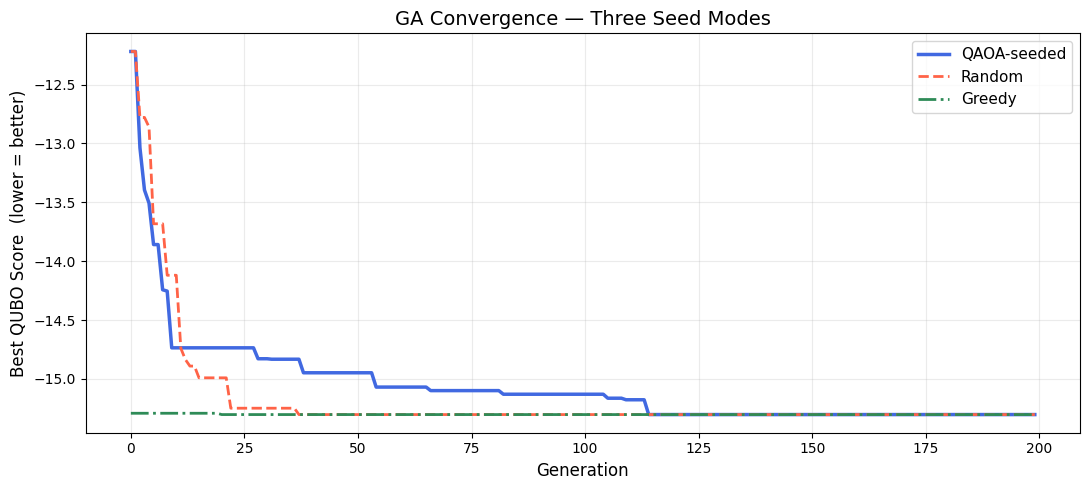

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 18. Convergence comparison — all three GA modes on one plot
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(11, 5))

if ga_qaoa_result is not None:
    ax.plot(ga_qaoa_result['convergence'],
            color='royalblue', linewidth=2.5, label='QAOA-seeded')

ax.plot(ga_random_result['convergence'],
        color='tomato', linewidth=2, linestyle='--', label='Random')

ax.plot(ga_greedy_result['convergence'],
        color='seagreen', linewidth=2, linestyle='-.', label='Greedy')

if full_optimal_score is not None:
    ax.axhline(full_optimal_score, color='black', linestyle=':', linewidth=1.5,
               label=f'BF optimal ({full_optimal_score:.4f})')

ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Best QUBO Score  (lower = better)', fontsize=12)
ax.set_title('GA Convergence — Three Seed Modes', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 19. Score comparison table
# ─────────────────────────────────────────────────────────────────────────────

rows = []

if full_optimal_score is not None:
    rows.append(['Brute Force', f'{full_optimal_score:.6f}', '—', '—',
                 sorted(full_optimal_cells)])

if qaoa_results_cells:  # guard against empty list (no feasible shots sampled)
    q_score, q_cells, q_prob = qaoa_results_cells[0]
    rows.append(['QAOA', f'{q_score:.6f}', '—', f'p={q_prob:.4f}', q_cells])

for label, result in [
    ('GA (QAOA-seed)', ga_qaoa_result),
    ('GA (Random)',    ga_random_result),
    ('GA (Greedy)',    ga_greedy_result),
]:
    if result is not None:
        rows.append([
            label,
            f'{result["best_score"]:.6f}',
            f'{result["runtime_sec"]:.2f}s',
            f'{result["n_generations_run"]} gens',
            result['best_solution'],
        ])

print(tabulate(
    rows,
    headers=['Method', 'Score', 'Runtime', 'Info', 'Best Cells'],
    tablefmt='simple',
))


Method             Score  Runtime    Info      Best Cells
--------------  --------  ---------  --------  ----------------------------------
QAOA            -11.8795  —          p=0.0002  [77, 116, 249, 324, 328, 332, 342]
GA (QAOA-seed)  -15.3023  1.30s      200 gens  [87, 168, 249, 253, 313, 324, 349]
GA (Random)     -15.3023  1.22s      200 gens  [87, 168, 249, 253, 313, 324, 349]
GA (Greedy)     -15.3023  1.23s      200 gens  [87, 168, 249, 253, 313, 324, 349]


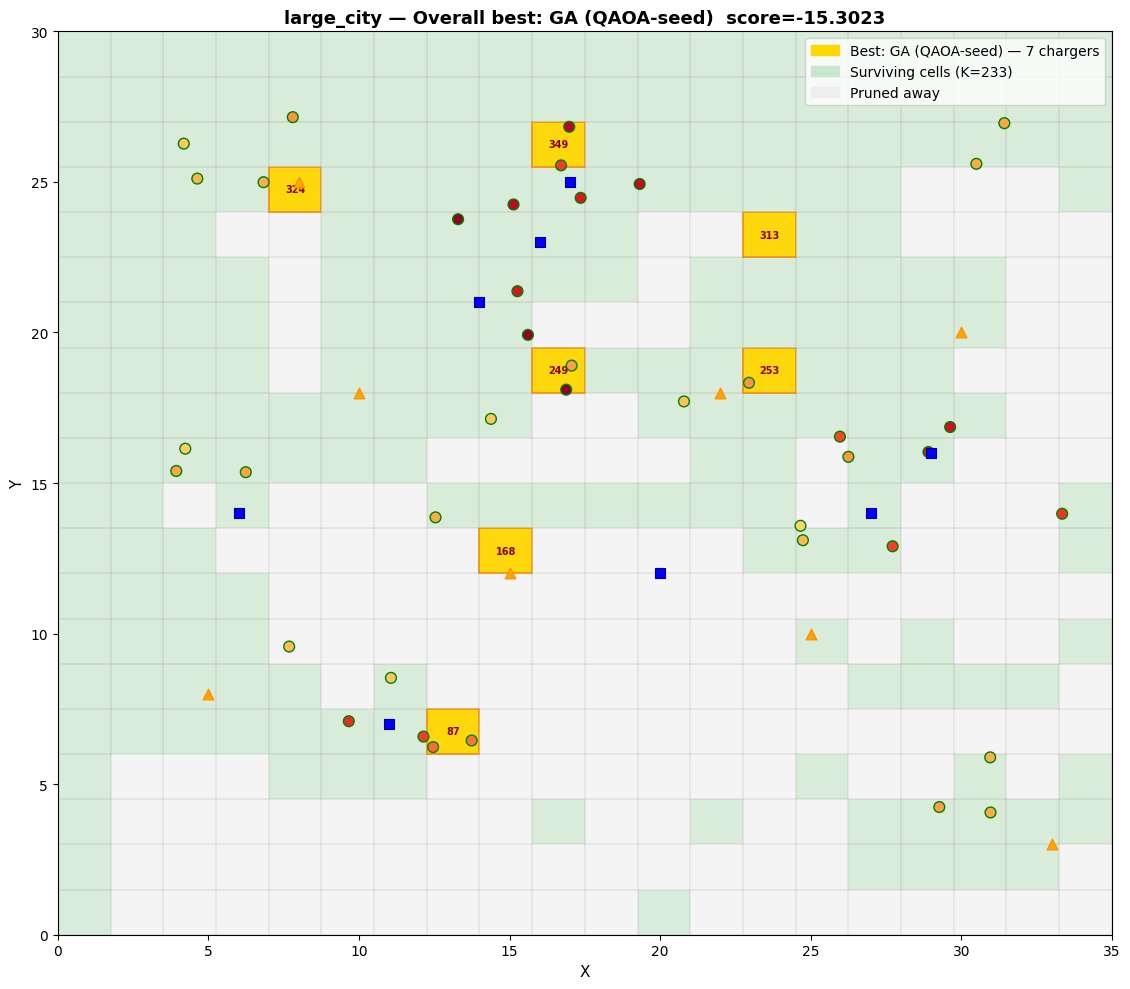

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# 23. Best solution — grid visualization
#     Compares ALL methods (BF, QAOA, GA×3) and highlights the globally best.
#     Gold  = chosen charger cells
#     Green = surviving (not selected)
#     Gray  = pruned away
# ─────────────────────────────────────────────────────────────────────────────

# Build a flat dict of every available result: label → (score, cells_list)
all_candidates = {}
if full_optimal_score is not None:
    all_candidates['Brute Force'] = (full_optimal_score, sorted(full_optimal_cells))
if qaoa_results_cells:  # guard against empty list (no feasible shots sampled)
    q_score, q_cells, _ = qaoa_results_cells[0]
    all_candidates['QAOA'] = (q_score, list(q_cells))
for label, result in [
    ('GA (QAOA-seed)', ga_qaoa_result),
    ('GA (Random)',    ga_random_result),
    ('GA (Greedy)',    ga_greedy_result),
]:
    if result is not None:
        all_candidates[label] = (result['best_score'], result['best_solution'])

overall_best_label  = min(all_candidates, key=lambda k: all_candidates[k][0])
overall_best_score  = all_candidates[overall_best_label][0]
overall_best_cells  = all_candidates[overall_best_label][1]
overall_best_set    = set(overall_best_cells)
surv_set            = set(surviving_cells)

num_rows = plot_deets['num_rows']
num_cols = plot_deets['num_cols']
cell_w   = plot_deets['cell_w']
cell_h   = plot_deets['cell_h']

fig_best, ax = plt.subplots(figsize=(12, 10))
ax.set_facecolor('#f8f8f8')

for i in range(num_cols + 1):
    ax.axvline(X_MIN + i * cell_w, color='gray', linestyle='-', linewidth=0.15)
for j in range(num_rows + 1):
    ax.axhline(Y_MIN + j * cell_h, color='gray', linestyle='-', linewidth=0.15)

for gid, info in grid_details.items():
    cx, cy = info['x_start'], info['y_start']
    if gid in overall_best_set:
        color, alpha, edge, ew = 'gold', 0.95, 'darkorange', 1.2
    elif gid in surv_set:
        color, alpha, edge, ew = '#c8e6c9', 0.65, 'lightgray', 0.15
    else:
        color, alpha, edge, ew = '#eeeeee', 0.30, 'lightgray', 0.10
    ax.add_patch(plt.Rectangle(
        (cx, cy), cell_w, cell_h,
        facecolor=color, alpha=alpha, edgecolor=edge, linewidth=ew,
    ))
    if gid in overall_best_set:
        ax.text(cx + cell_w / 2, cy + cell_h / 2, str(gid),
                ha='center', va='center', fontsize=7, fontweight='bold', color='darkred')

if points_of_interest:
    ax.scatter([p[0] for p in points_of_interest],
               [p[1] for p in points_of_interest],
               c=[p[2] for p in points_of_interest], cmap='YlOrRd',
               edgecolors='green', linewidths=1, s=60, vmin=0, vmax=1, zorder=5)
if existing_charging_points:
    ax.scatter(*zip(*existing_charging_points), color='blue', marker='s',
               s=60, zorder=5, edgecolors='darkblue', linewidths=0.8)
if gas_stations:
    ax.scatter(*zip(*gas_stations), color='orange', marker='^',
               s=60, zorder=5, edgecolors='darkorange', linewidths=0.8)

legend_patches = [
    mpatches.Patch(color='gold',    label=f'Best: {overall_best_label} — {M} chargers'),
    mpatches.Patch(color='#c8e6c9', label=f'Surviving cells (K={K})'),
    mpatches.Patch(color='#eeeeee', label='Pruned away'),
]
ax.legend(handles=legend_patches, loc='upper right', fontsize=10)
ax.set_xlim(X_MIN, X_MAX); ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xlabel('X', fontsize=11); ax.set_ylabel('Y', fontsize=11)
ax.set_title(
    f"{data['dataset_name']} — Overall best: {overall_best_label}  score={overall_best_score:.4f}",
    fontsize=13, fontweight='bold',
)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# 21. Pipeline summary
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 70)
print("PIPELINE SUMMARY — HGQA mk07")
print("=" * 70)
print(f"  Dataset   : {data['dataset_name']}")
print(f"  Grid      : {N_QUBITS} cells ({plot_deets['num_rows']}×{plot_deets['num_cols']})")
print(f"  POIs      : {len(points_of_interest)}")
print(f"  Chargers  : {len(existing_charging_points)} existing, {M} new to place")
print(f"  Gas       : {len(gas_stations)}")
print(f"  Pruning   : {N_QUBITS} → {K} ({100*(1-K/N_QUBITS):.0f}% reduction)")
print(f"    Tier 1  : {prune_report['tier1']['pruned']} pruned  (dead cells)")
print(f"    Tier 2  : {prune_report['tier2']['pruned']} pruned  (bound elim)")
print(f"    Tier 3  : {prune_report['tier3']['pruned']} pruned  (spatial dedup)")
print(f"  Search    : C({N_QUBITS},{M})={math.comb(N_QUBITS,M):,} → "
      f"C({K},{M})={math.comb(K,M):,}")
print()

if full_optimal_score is not None:
    print(f"  BF optimal      : {full_optimal_score:.6f}  cells={sorted(full_optimal_cells)}")
if qaoa_results_cells:  # guard against empty list (no feasible shots sampled)
    print(f"  QAOA ({qaoa_mode:11s}): {qaoa_results_cells[0][0]:.6f}  "
          f"cells={qaoa_results_cells[0][1]}")
for label, result in [
    ('GA QAOA-seed  ', ga_qaoa_result),
    ('GA Random     ', ga_random_result),
    ('GA Greedy     ', ga_greedy_result),
]:
    if result is not None:
        print(f"  {label}: {result['best_score']:.6f}  cells={result['best_solution']}")

print()
print(f"  Overall best      : {overall_best_score:.6f}  ({overall_best_label})  cells={overall_best_cells}")
print("=" * 70)


PIPELINE SUMMARY — HGQA mk07
  Dataset   : large_city
  Grid      : 400 cells (20×20)
  POIs      : 40
  Chargers  : 8 existing, 7 new to place
  Gas       : 8
  Pruning   : 400 → 233 (42% reduction)
    Tier 1  : 0 pruned  (dead cells)
    Tier 2  : 0 pruned  (bound elim)
    Tier 3  : 167 pruned  (spatial dedup)
  Search    : C(400,7)=308,364,541,201,200 → C(233,7)=6,753,818,290,868

  QAOA (mps        ): -11.879508  cells=[77, 116, 249, 324, 328, 332, 342]
  GA QAOA-seed  : -15.302332  cells=[87, 168, 249, 253, 313, 324, 349]
  GA Random     : -15.302332  cells=[87, 168, 249, 253, 313, 324, 349]
  GA Greedy     : -15.302332  cells=[87, 168, 249, 253, 313, 324, 349]

  Overall best      : -15.302332  (GA (QAOA-seed))  cells=[87, 168, 249, 253, 313, 324, 349]


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# 25. Save results
#     Folder: results/{dataset}_{N_QUBITS}/run_N/
#     Saves : convergence.png, best_solution.png, pruning.png, summary.json
# ─────────────────────────────────────────────────────────────────────────────

import json as _json
from datetime import datetime
from pathlib import Path as _Path

_proj_root_r = _Path.cwd().parent
_run_tag     = f"{data['dataset_name']}_{N_QUBITS}q"
_base_dir    = _proj_root_r / 'results' / _run_tag

# Auto-increment run index
_run_idx = 0
while (_base_dir / f"run_{_run_idx}").exists():
    _run_idx += 1
_run_dir = _base_dir / f"run_{_run_idx}"
_run_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving to: {_run_dir}")

# ── 1. Convergence plot ───────────────────────────────────────────────────────
_fig_conv, _ax_conv = plt.subplots(figsize=(11, 5))
if ga_qaoa_result is not None:
    _ax_conv.plot(ga_qaoa_result['convergence'], color='royalblue', linewidth=2.5, label='QAOA-seeded')
_ax_conv.plot(ga_random_result['convergence'], color='tomato', linewidth=2, linestyle='--', label='Random')
_ax_conv.plot(ga_greedy_result['convergence'], color='seagreen', linewidth=2, linestyle='-.', label='Greedy')
if full_optimal_score is not None:
    _ax_conv.axhline(full_optimal_score, color='black', linestyle=':', linewidth=1.5,
                     label=f'BF optimal ({full_optimal_score:.4f})')
_ax_conv.set_xlabel('Generation'); _ax_conv.set_ylabel('Best QUBO Score (lower = better)')
_ax_conv.set_title('GA Convergence — Three Seed Modes'); _ax_conv.legend(); _ax_conv.grid(True, alpha=0.25)
_fig_conv.tight_layout()
_fig_conv.savefig(_run_dir / 'convergence.png', dpi=150, bbox_inches='tight')
plt.close(_fig_conv)
print("  convergence.png  saved")

# ── 2. Best solution grid ─────────────────────────────────────────────────────
_surv_set = set(surviving_cells)
_fig_sol, _ax_sol = plt.subplots(figsize=(12, 10))
_ax_sol.set_facecolor('#f8f8f8')
for _i in range(plot_deets['num_cols'] + 1):
    _ax_sol.axvline(X_MIN + _i * plot_deets['cell_w'], color='gray', linewidth=0.15)
for _j in range(plot_deets['num_rows'] + 1):
    _ax_sol.axhline(Y_MIN + _j * plot_deets['cell_h'], color='gray', linewidth=0.15)
for _gid, _info in grid_details.items():
    _cx, _cy = _info['x_start'], _info['y_start']
    if _gid in overall_best_set:
        _col, _al, _ed, _ew = 'gold', 0.95, 'darkorange', 1.2
    elif _gid in _surv_set:
        _col, _al, _ed, _ew = '#c8e6c9', 0.65, 'lightgray', 0.15
    else:
        _col, _al, _ed, _ew = '#eeeeee', 0.30, 'lightgray', 0.10
    _ax_sol.add_patch(plt.Rectangle((_cx, _cy), plot_deets['cell_w'], plot_deets['cell_h'],
                                    facecolor=_col, alpha=_al, edgecolor=_ed, linewidth=_ew))
    if _gid in overall_best_set:
        _ax_sol.text(_cx + plot_deets['cell_w']/2, _cy + plot_deets['cell_h']/2, str(_gid),
                     ha='center', va='center', fontsize=7, fontweight='bold', color='darkred')
if points_of_interest:
    _ax_sol.scatter([p[0] for p in points_of_interest], [p[1] for p in points_of_interest],
                    c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                    edgecolors='green', linewidths=1, s=60, vmin=0, vmax=1, zorder=5)
if existing_charging_points:
    _ax_sol.scatter(*zip(*existing_charging_points), color='blue', marker='s',
                    s=60, zorder=5, edgecolors='darkblue', linewidths=0.8)
if gas_stations:
    _ax_sol.scatter(*zip(*gas_stations), color='orange', marker='^',
                    s=60, zorder=5, edgecolors='darkorange', linewidths=0.8)
_ax_sol.set_xlim(X_MIN, X_MAX); _ax_sol.set_ylim(Y_MIN, Y_MAX)
_ax_sol.set_aspect('equal')
_ax_sol.set_title(f"{data['dataset_name']} — {overall_best_label}  score={overall_best_score:.4f}",
                  fontsize=13, fontweight='bold')
_fig_sol.tight_layout()
_fig_sol.savefig(_run_dir / 'best_solution.png', dpi=150, bbox_inches='tight')
plt.close(_fig_sol)
print("  best_solution.png saved")

# ── 3. Pruning comparison (before / after) ────────────────────────────────────
_solos = compute_solo_scores(Q_obj, N_QUBITS)
_fig_pr, _axes_pr = plt.subplots(1, 2, figsize=(18, 8))
for _ax_p, _title_p, _hl_p in zip(
    _axes_pr,
    [f'All {N_QUBITS} cells', f'After pruning (K={K})'],
    [set(range(N_QUBITS)), set(surviving_cells)],
):
    _ax_p.set_facecolor('white')
    for _ii in range(plot_deets['num_cols'] + 1):
        _ax_p.axvline(X_MIN + _ii * plot_deets['cell_w'], color='gray', linewidth=0.2)
    for _jj in range(plot_deets['num_rows'] + 1):
        _ax_p.axhline(Y_MIN + _jj * plot_deets['cell_h'], color='gray', linewidth=0.2)
    for _gid, _info in grid_details.items():
        _in_hl = _gid in _hl_p
        _sc    = _solos[_gid] if _in_hl else 0
        _col_p = plt.cm.Greens(max(0, min(1, -_sc / 3.0))) if _in_hl else (0.93, 0.93, 0.93)
        _al_p  = 0.8 if _in_hl else 0.3
        _ax_p.add_patch(plt.Rectangle((_info['x_start'], _info['y_start']),
                                      plot_deets['cell_w'], plot_deets['cell_h'],
                                      facecolor=_col_p, alpha=_al_p, edgecolor='lightgray', linewidth=0.2))
    if points_of_interest:
        _ax_p.scatter([p[0] for p in points_of_interest], [p[1] for p in points_of_interest],
                      c=[p[2] for p in points_of_interest], cmap='YlOrRd',
                      edgecolors='green', s=50, vmin=0, vmax=1, zorder=5)
    _ax_p.set_xlim(X_MIN, X_MAX); _ax_p.set_ylim(Y_MIN, Y_MAX)
    _ax_p.set_title(_title_p, fontsize=12); _ax_p.set_aspect('equal')
_fig_pr.suptitle(f"{data['dataset_name']} — N={N_QUBITS}, m={M}", fontsize=14, fontweight='bold')
_fig_pr.tight_layout()
_fig_pr.savefig(_run_dir / 'pruning.png', dpi=150, bbox_inches='tight')
plt.close(_fig_pr)
print("  pruning.png      saved")

# ── 4. JSON summary ────────────────────────────────────────────────────────────
def _ga_dict(res):
    if res is None: return None
    return {"best_score": res["best_score"], "best_cells": res["best_solution"],
            "runtime_sec": round(res["runtime_sec"], 3), "n_generations": res["n_generations_run"]}

_summary = {
    "timestamp":       datetime.now().isoformat(timespec='seconds'),
    "dataset":         data['dataset_name'],
    "N_qubits":        N_QUBITS,
    "K_pruned":        K,
    "tier3_keep_used": tier3_keep_used,
    "m_chargers":      M,
    "pruning": {
        "original_N":    N_QUBITS,
        "surviving_K":   K,
        "reduction_pct": round(100*(1 - K/N_QUBITS), 1),
        "tier1_pruned":  prune_report["tier1"]["pruned"],
        "tier2_pruned":  prune_report["tier2"]["pruned"],
        "tier3_pruned":  prune_report["tier3"]["pruned"],
    },
    "brute_force": None if full_optimal_score is None else {
        "score": full_optimal_score, "cells": sorted(full_optimal_cells)
    },
    "qaoa": None if not qaoa_results_cells else {
        "mode":       qaoa_mode,
        "best_score": qaoa_results_cells[0][0],
        "best_cells": qaoa_results_cells[0][1],
        "params":     qaoa_params.tolist() if qaoa_params is not None else None,
    },
    "ga": {
        "qaoa_seed": _ga_dict(ga_qaoa_result),
        "random":    _ga_dict(ga_random_result),
        "greedy":    _ga_dict(ga_greedy_result),
    },
    "overall_best": {
        "method": overall_best_label,
        "score":  overall_best_score,
        "cells":  overall_best_cells,
    },
}
(_run_dir / 'summary.json').write_text(_json.dumps(_summary, indent=2))
print("  summary.json     saved")
print(f"\nAll results saved → {_run_dir}")


Saving to: /Users/abhimuvva/Documents/Proj_HGQA/results/large_city_400q/run_0
  convergence.png  saved
  best_solution.png saved
  pruning.png      saved
  summary.json     saved

All results saved → /Users/abhimuvva/Documents/Proj_HGQA/results/large_city_400q/run_0
